In [145]:
import numpy as np

from pybatteryid.utilities import load_model_from_file, invert_voltage_function
from pybatteryid.plotter import plot_time_vs_current

from pybatteryse.filters import ExtendedKalmanFilter
from pybatteryse.plotter import plot_time_vs_parameter

from data import helper

### Load identified model and test dataset

We have included multiple datasets representing drive-cycle data obtained from a 2.85 Ah NMC cell at different stages in its life, i.e., when the battery capacity is (i) 98%, (ii) 94%, and (iii) 85% of its rated capacity value.

In [146]:
model = load_model_from_file('data/nmc_with_ageing/capacity_98%/model_n,l=1,1.npy')
dataset = helper.load_npy_datasets(f'data/nmc_with_ageing/capacity_98%/drive_cycle_data.npy')

In [147]:
current_values = dataset['current_values']
voltage_values = dataset['voltage_values']
temperature_values = dataset['temperature_values']

# We use correct initial SOC here.
initial_soc = invert_voltage_function(model.emf_function, voltage_values[0])

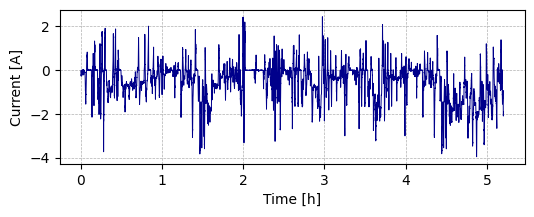

In [148]:
plot_time_vs_current([(dataset['time_values'] / 3600, dataset['current_values'])],
                     units=('h', 'A'), colors=['darkblue'])

### Load EKF and run it on the dataset

In [149]:
ekf = ExtendedKalmanFilter(model, sigma_nu=1e-3, sigma_ny_ne=1e-3)

We can update the model parameters using the values learned from the training cells. Essentially, we identified models for a collection of training cells, and calculated mean parameter values. We expect that most of these values would be the same for the unseen test cell.

In [150]:
ekf.modify_model_parameters([0.3243599634590211, 0.0016222701892434582, # <--- y_{k-1}
                             0.017607961202546644, 0.0003176717201218238, -0.0011110135791564163, # <--- u_k
                             -0.014322342426930664, -0.00020490084950971742, -0.001558389175651483]) # <--- u_{k-1}

While we keep most parameters fixed, we do select parameters that capture ageing-dependent behaviour. We call them free parameters, and estimate them along with battery capacity and other states.

In [151]:
ekf.extend_state(['theta_3', 'theta_6', 'capacity'], [1e-12, 1e-12, 0.1])

We can now run our EKF. We provide initial values for the free parameters equal to the mean values given above. However, these parameters are now freely estimated using the EKF.

In [152]:
# Set initial conditions
initial_state = np.vstack(( [initial_soc], [0], [0.017607961202546644], [-0.014322342426930664], [10300] ))
initial_covariance = np.zeros((len(initial_state), len(initial_state)))

state_estimates = ekf.run(
    temperature_values=temperature_values,
    current_values=current_values,
    voltage_values=voltage_values,
    initial_state=initial_state,
    initial_covariance=initial_covariance,
)

# Extract relevant trajectories
soc_est = state_estimates[:, 0]
theta_3_est = state_estimates[:, 2]
theta_6_est = state_estimates[:, 3]
capacity_est = state_estimates[:, 4]

EKF Progress: 100%|███████████████████████████████████████| 18739/18739 [00:11<00:00, 1591.14step/s]


We now compare the estimated parameter values with the "true" values that were estimated offline for the test cell using more informative identification datasets.

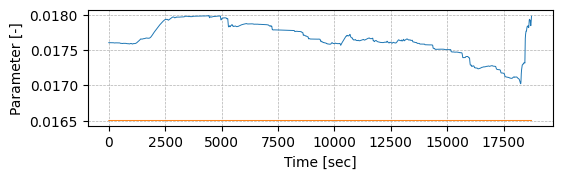

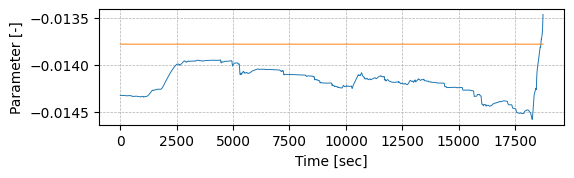

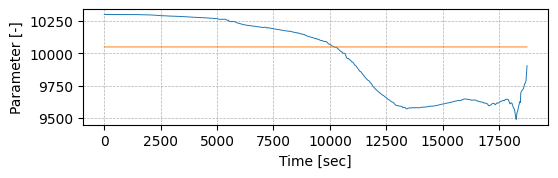

In [155]:
theta_3_true_value = model.model_estimate[2]
theta_6_true_value = model.model_estimate[5]
capacity_true_value = model.battery_capacity

#
plot_time_vs_parameter([(dataset['time_values'], theta_3_est),
                        (dataset['time_values'], [theta_3_true_value] * len(dataset['time_values']))], figsize=(6,1.5))
plot_time_vs_parameter([(dataset['time_values'], theta_6_est),
                        (dataset['time_values'], [theta_6_true_value] * len(dataset['time_values']))], figsize=(6,1.5))
plot_time_vs_parameter([(dataset['time_values'], capacity_est),
                        (dataset['time_values'], [capacity_true_value] * len(dataset['time_values']))], figsize=(6,1.5))